# Student Habits & Academic Performance Project

This notebook will handle all the data cleaning, validation, featurization, and train/test splitting before any modelling takes place. This is because we wanted to standardize any data pre-processing so that the models we work on are easily comparable.
The pre-processed data will be used by our following models:
- Linear Regression
- Ridge / Lasso Regression
- Decision Trees
- Neural Networks

**Target Variable:**
- exam_score (primary regression target)

In [5]:
"""
Importing the required libraries and the raw data that we will be working on.
"""
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import (
    StandardScaler, MinMaxScaler,
    LabelEncoder, OrdinalEncoder
)
from sklearn.impute import SimpleImputer
import joblib, os

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_theme(style='whitegrid')

OUT_DIR = './processed'
os.makedirs(OUT_DIR, exist_ok=True)

data = pd.read_csv('../project/data.csv')

print(f'Shape : {data.shape}')
print(f'Columns ({len(data.columns)}):')
print(data.columns.tolist())
data.head(5)

Shape : (80000, 31)
Columns (31):
['student_id', 'age', 'gender', 'major', 'study_hours_per_day', 'social_media_hours', 'netflix_hours', 'part_time_job', 'attendance_percentage', 'sleep_hours', 'diet_quality', 'exercise_frequency', 'parental_education_level', 'internet_quality', 'mental_health_rating', 'extracurricular_participation', 'previous_gpa', 'semester', 'stress_level', 'dropout_risk', 'social_activity', 'screen_time', 'study_environment', 'access_to_tutoring', 'family_income_range', 'parental_support_level', 'motivation_level', 'exam_anxiety_score', 'learning_style', 'time_management_score', 'exam_score']


,student_id,age,gender,major,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,...,screen_time,study_environment,access_to_tutoring,family_income_range,parental_support_level,motivation_level,exam_anxiety_score,learning_style,time_management_score,exam_score
0,100000,26,Male,Computer Science,7.645367,3.0,0.1,Yes,70.3,6.2,...,10.9,Co-Learning Group,Yes,High,9,7,8,Reading,3.0,100
1,100001,28,Male,Arts,5.700000,0.5,0.4,No,88.4,7.2,...,8.3,Co-Learning Group,Yes,Low,7,2,10,Reading,6.0,99
2,100002,17,Male,Arts,2.400000,4.2,0.7,No,82.1,9.2,...,8.0,Library,Yes,High,3,9,6,Kinesthetic,7.6,98
3,100003,27,Other,Psychology,3.400000,4.6,2.3,Yes,79.3,4.2,...,11.7,Co-Learning Group,Yes,Low,5,3,10,Reading,3.2,100
4,100004,25,Female,Business,4.700000,0.8,2.7,Yes,62.9,6.5,...,9.4,Quiet Room,Yes,Medium,9,1,10,Reading,7.1,98


In [6]:
"""
Dropping ID/leakage columns from the dataset.

- student_id: This field is a meaningless primary key for the dataset. It does not encode any real information about the rest of the data in that row that will help us.

- previous_gpa: ???
"""
df = data.drop(columns=['student_id'], errors='ignore').copy()
# TODO: Drop previous_gpa

print(f'Shape after ID drop: {df.shape}')
df.head(5)

Shape after ID drop: (80000, 30)


,age,gender,major,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,...,screen_time,study_environment,access_to_tutoring,family_income_range,parental_support_level,motivation_level,exam_anxiety_score,learning_style,time_management_score,exam_score
0,26,Male,Computer Science,7.645367,3.0,0.1,Yes,70.3,6.2,Poor,...,10.9,Co-Learning Group,Yes,High,9,7,8,Reading,3.0,100
1,28,Male,Arts,5.700000,0.5,0.4,No,88.4,7.2,Good,...,8.3,Co-Learning Group,Yes,Low,7,2,10,Reading,6.0,99
2,17,Male,Arts,2.400000,4.2,0.7,No,82.1,9.2,Good,...,8.0,Library,Yes,High,3,9,6,Kinesthetic,7.6,98
3,27,Other,Psychology,3.400000,4.6,2.3,Yes,79.3,4.2,Fair,...,11.7,Co-Learning Group,Yes,Low,5,3,10,Reading,3.2,100
4,25,Female,Business,4.700000,0.8,2.7,Yes,62.9,6.5,Good,...,9.4,Quiet Room,Yes,Medium,9,1,10,Reading,7.1,98


### Auditing Data-Types & Missing Values

In [7]:
print("Data Types: \n", df.dtypes)
print()

missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_report = pd.DataFrame({'missing_count': missing, 'missing_%': missing_pct})
missing_report = missing_report[missing_report['missing_count'] > 0].sort_values('missing_%', ascending=False)

if missing_report.empty:
    print('No missing values found.')
else:
    print('Missing values found:')
    display(missing_report)

Data Types: 
 age                                int64
gender                               str
major                                str
study_hours_per_day              float64
social_media_hours               float64
netflix_hours                    float64
part_time_job                        str
attendance_percentage            float64
sleep_hours                      float64
diet_quality                         str
exercise_frequency                 int64
parental_education_level             str
internet_quality                     str
mental_health_rating             float64
extracurricular_participation        str
previous_gpa                     float64
semester                           int64
stress_level                     float64
dropout_risk                         str
social_activity                    int64
screen_time                      float64
study_environment                    str
access_to_tutoring                   str
family_income_range                  str
pa

In [8]:
"""
Getting a quick description of the dataset's numertical values.
"""
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,80000.0,22.004288,3.745570,16.00,19.00,22.000000,25.0,28.0
study_hours_per_day,80000.0,4.174388,2.004135,0.00,2.80,4.125624,5.5,12.0
social_media_hours,80000.0,2.501366,1.445441,0.00,1.20,2.500000,3.8,5.0
netflix_hours,80000.0,1.997754,1.155992,0.00,1.00,2.000000,3.0,4.0
attendance_percentage,80000.0,69.967884,17.333015,40.00,55.00,69.900000,84.9,100.0
sleep_hours,80000.0,7.017418,1.467377,4.00,6.00,7.000000,8.0,12.0
exercise_frequency,80000.0,3.516587,2.291575,0.00,2.00,4.000000,6.0,7.0
mental_health_rating,80000.0,6.804108,1.921579,1.00,5.50,6.900000,8.2,10.0
previous_gpa,80000.0,3.602448,0.462876,1.64,3.27,3.790000,4.0,4.0
semester,80000.0,4.497338,2.295312,1.00,2.00,5.000000,7.0,8.0


### Normalizing Boolean Data-Types

In [11]:
boolean_types = ['part_time_job', 'extracurricular_participation', 'access_to_tutoring', 'dropout_risk']

for col in boolean_types:
    df[col] = (
        df[col]
        .astype(str)
        .str.strip()
        .str.lower()
        .map({'yes': 1, 'no': 0, 'true': 1, 'false': 0})
    )

print(df[['part_time_job']].value_counts())

part_time_job
0                40195
1                39805
Name: count, dtype: int64


### Dealing with Missing Values
- **Numeric Values** → Median (robust to outliers)
- **Categorical** → Mode (most frequent class)

In [12]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include='object').columns.tolist()

num_predictors = [c for c in numeric_cols if c not in 'exam_score']
cat_predictors = [c for c in categorical_cols if c not in 'exam_score']

if num_predictors:
    num_imputer = SimpleImputer(strategy='median')
    df[num_predictors] = num_imputer.fit_transform(df[num_predictors])

if cat_predictors:
    cat_imputer = SimpleImputer(strategy='most_frequent')
    df[cat_predictors] = cat_imputer.fit_transform(df[cat_predictors])

print(f'Post-Imputation, there should be no missing values: {df.isnull().sum().sum()}')

/var/folders/3x/d1d7nq7n77qd1w8x86hjv6q80000gn/T/ipykernel_7339/4288015387.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include='object').columns.tolist()


Post-Imputation, there should be no missing values: 0


### 2.6 · Ordinal Encoding - Giving Integer Rankings to Categorial Variables with Progressive Relationships
Ex: Low = 1, Medium = 2, High = 3

In [14]:
ORDINAL_MAPS = {
    'parental_support_level': ['None', 'Low', 'Medium', 'High', 'Very High'],
    'parental_education_level': ['None', 'High School', 'Some College', "Bachelor's", "Master's", 'PhD'],
    'family_income_range': ['Low', 'Medium', 'High'],
    'diet_quality': ['Poor', 'Fair', 'Good'],
    'stress_level': ['Low', 'Moderate', 'High'],
    'motivation_level': ['Low', 'Medium', 'High'],
}

for col, order in ORDINAL_MAPS.items():
    if col not in df.columns:
        continue

    df[col] = df[col].astype(str).str.strip()
    mapping = {level: idx for idx, level in enumerate(order)}
    df[col] = df[col].map(mapping)

    # Fill NaN safely
    median_val = df[col].median()
    df[col] = df[col].fillna(median_val)

    # Convert to nullable integer type
    df[col] = df[col].astype('Int64')

    print(f'  {col}: {mapping}')

print('\nOrdinal encoding complete.')

  parental_support_level: {'None': 0, 'Low': 1, 'Medium': 2, 'High': 3, 'Very High': 4}
  parental_education_level: {'None': 0, 'High School': 1, 'Some College': 2, "Bachelor's": 3, "Master's": 4, 'PhD': 5}
  family_income_range: {'Low': 0, 'Medium': 1, 'High': 2}
  diet_quality: {'Poor': 0, 'Fair': 1, 'Good': 2}
  stress_level: {'Low': 0, 'Moderate': 1, 'High': 2}
  motivation_level: {'Low': 0, 'Medium': 1, 'High': 2}

Ordinal encoding complete.


### 2.7 · One-Hot Encode Nominal Categoricals

Remaining string columns have **no intrinsic order** → dummy variables.

Typical nominal columns: `gender`, `major`, `learning_style`, `study_environment`.

In [16]:
TARGETS = ['dropout_risk']

# Identifying remaining object/string columns that weren't ordinal-encoded
nominal_cols = df.select_dtypes(include='string').columns.tolist()
nominal_cols = [c for c in nominal_cols if c not in TARGETS]

print(f'Nominal columns to one-hot encode: {nominal_cols}')

df = pd.get_dummies(df, columns=nominal_cols, drop_first=False)
# Note for Harsh: drop_first=False → keep all dummies; regularization in Ridge/Lasso handles multicollinearity.

print(f'Shape after one-hot encoding: {df.shape}')
print('New columns added:')
print([c for c in df.columns if any(c.startswith(n+'_') for n in nominal_cols)])

Nominal columns to one-hot encode: ['gender', 'major', 'internet_quality', 'study_environment', 'learning_style']
Shape after one-hot encoding: (80000, 46)
New columns added:
['gender_Female', 'gender_Male', 'gender_Other', 'major_Arts', 'major_Biology', 'major_Business', 'major_Computer Science', 'major_Engineering', 'major_Psychology', 'internet_quality_High', 'internet_quality_Low', 'internet_quality_Medium', 'study_environment_Cafe', 'study_environment_Co-Learning Group', 'study_environment_Dorm', 'study_environment_Library', 'study_environment_Quiet Room', 'learning_style_Auditory', 'learning_style_Kinesthetic', 'learning_style_Reading', 'learning_style_Visual']


### 2.8 · Clip / Fix Known Range Anomalies

The dataset documentation specifies hard bounds for several fields.
We clip rather than drop to preserve all 80 000 rows.

In [17]:
CLIP_RULES = {
    'age':                       (16, 28),
    'study_hours_per_day':       (0, 24),
    'social_media_hours':        (0, 24),
    'netflix_hours':             (0, 24),
    'screen_time':               (0, 24),
    'attendance_percentage':     (0, 100),
    'sleep_hours':               (0, 24),
    'exercise_frequency':        (0, 7),
    'mental_health_rating':      (1, 10),
    'exam_anxiety_score':        (1, 10),
    'time_management_score':     (1, 10),
    'exam_score':                (0, 100),
    'previous_gpa':              (0, 4),
}

for col, (lo, hi) in CLIP_RULES.items():
    if col in df.columns:
        n_clipped = ((df[col] < lo) | (df[col] > hi)).sum()
        if n_clipped:
            print(f'  {col}: clipped {n_clipped} values to [{lo}, {hi}]')
        df[col] = df[col].clip(lo, hi)

print('Range clipping complete.')

Range clipping complete.


### 2.9 · Feature Engineering

We create a handful of **interpretable composite features** that may carry stronger
signal than the raw inputs.

| New feature | Formula | Rationale |
|-------------|---------|----------|
| `total_screen_time` | `social_media_hours + netflix_hours + screen_time` | Aggregate distraction load |
| `study_to_screen_ratio` | `study_hours / (total_screen_time + 0.1)` | Productive vs idle time |
| `sleep_study_balance` | `sleep_hours + study_hours_per_day` | Combined restorative + work load |
| `stress_anxiety_composite` | `(stress_level + exam_anxiety_score) / 2` | Combined psychological pressure |
| `support_composite` | `parental_support_level + access_to_tutoring` | Total external support |
| `wellness_score` | `mental_health_rating + (sleep/12)*10 + (exercise/7)*10` | Holistic wellbeing proxy |

In [18]:
screen_cols = [c for c in ['social_media_hours', 'netflix_hours', 'screen_time'] if c in df.columns]
df['total_screen_time'] = df[screen_cols].sum(axis=1)

df['study_to_screen_ratio'] = df['study_hours_per_day'] / (df['total_screen_time'] + 0.1)

df['sleep_study_balance'] = df['sleep_hours'] + df['study_hours_per_day']

if 'stress_level' in df.columns and 'exam_anxiety_score' in df.columns:
    df['stress_anxiety_composite'] = (df['stress_level'] + df['exam_anxiety_score']) / 2

support_parts = [c for c in ['parental_support_level', 'access_to_tutoring'] if c in df.columns]
df['support_composite'] = df[support_parts].sum(axis=1)

df['wellness_score'] = (
    df.get('mental_health_rating', pd.Series(0, index=df.index))
    + (df.get('sleep_hours', pd.Series(0, index=df.index)) / 12 * 10)
    + (df.get('exercise_frequency', pd.Series(0, index=df.index)) / 7 * 10)
)

print('Engineered features added:')
eng_feats = ['total_screen_time', 'study_to_screen_ratio', 'sleep_study_balance',
             'stress_anxiety_composite', 'support_composite', 'wellness_score']
print(df[[f for f in eng_feats if f in df.columns]].describe().T.round(3))

Engineered features added:
                            count       mean       std       min       25%  \
total_screen_time         80000.0  14.172149  4.233735       0.6      11.2   
study_to_screen_ratio     80000.0    0.30018    0.1432       0.0  0.206349   
sleep_study_balance       80000.0  11.191806  2.483487       4.0       9.5   
stress_anxiety_composite      0.0       <NA>      <NA>      <NA>      <NA>   
support_composite         80000.0   0.499513  0.500003       0.0       0.0   
wellness_score            80000.0  17.675652   3.98803  4.633333  14.72381   

                                50%        75%       max  
total_screen_time              14.2       17.1      29.7  
study_to_screen_ratio      0.291339   0.384106  0.969231  
sleep_study_balance            11.2       12.9      21.2  
stress_anxiety_composite       <NA>       <NA>      <NA>  
support_composite               0.0        1.0       1.0  
wellness_score            17.697619  20.654762      30.0  


### 2.10 · Correlation / Collinearity Check

We inspect the numeric feature correlations for:
1. **Correlation with `exam_score`** — helps rank feature importance visually.
2. **High inter-feature correlation (|r| > 0.90)** — flags pairs that could destabilise linear model coefficients.

Top 15 features correlated with exam_score:
previous_gpa             0.933
sleep_study_balance      0.249
study_hours_per_day      0.241
exam_anxiety_score      -0.236
study_to_screen_ratio    0.184
screen_time              0.170
support_composite        0.120
access_to_tutoring       0.120
total_screen_time        0.109
wellness_score           0.104
sleep_hours              0.091
dropout_risk            -0.088
exercise_frequency       0.087
mental_health_rating     0.011
social_media_hours      -0.006
Name: exam_score, dtype: float64


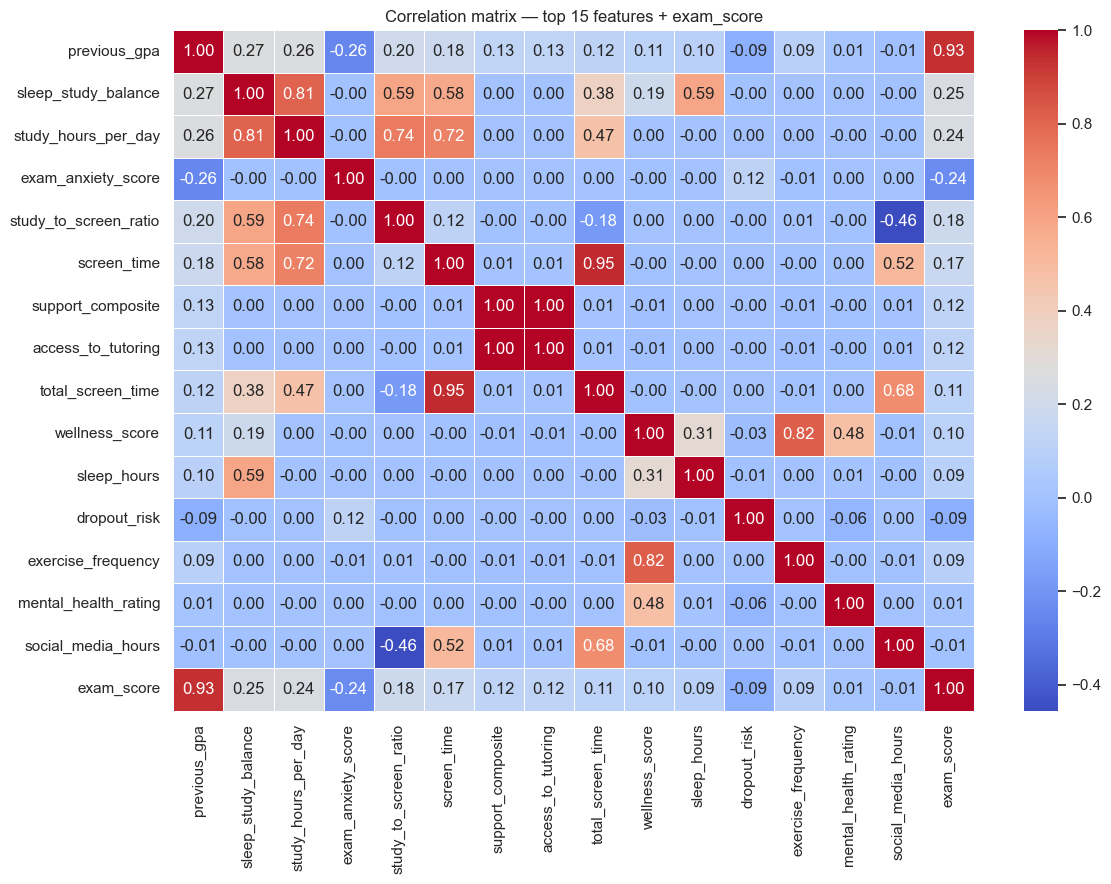

In [19]:
numeric_df = df.select_dtypes(include=[np.number])

if 'exam_score' in numeric_df.columns:
    target_corr = numeric_df.corr()['exam_score'].drop('exam_score').sort_values(key=abs, ascending=False)
    print('Top 15 features correlated with exam_score:')
    print(target_corr.head(15).round(3))

    top15 = target_corr.head(15).index.tolist() + ['exam_score']
    plt.figure(figsize=(12, 9))
    sns.heatmap(numeric_df[top15].corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.4)
    plt.title('Correlation matrix — top 15 features + exam_score')
    plt.tight_layout()
    plt.show()

In [20]:
corr_matrix = numeric_df.corr().abs()
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr_pairs = (
    upper_tri.stack()
    .reset_index()
    .rename(columns={'level_0': 'feature_1', 'level_1': 'feature_2', 0: 'r'})
    .query('r > 0.90')
    .sort_values('r', ascending=False)
)

if high_corr_pairs.empty:
    print('No feature pairs with |r| > 0.90 found.')
else:
    print('High-correlation pairs (|r| > 0.90):')
    display(high_corr_pairs)
    print()
    print('Note: Ridge/Lasso handle collinearity via regularisation.')
    print('For vanilla Linear Regression consider dropping one column of each pair.')

High-correlation pairs (|r| > 0.90):


,feature_1,feature_2,r
587,access_to_tutoring,support_composite,1.000000
552,screen_time,total_screen_time,0.945057
396,previous_gpa,exam_score,0.932940



Note: Ridge/Lasso handle collinearity via regularisation.
For vanilla Linear Regression consider dropping one column of each pair.


In [21]:
COLS_TO_DROP_COLLINEAR = ['screen_time']
df.drop(columns=[c for c in COLS_TO_DROP_COLLINEAR if c in df.columns], inplace=True)
print(f'Dropped {COLS_TO_DROP_COLLINEAR}. Shape now: {df.shape}')

Dropped ['screen_time']. Shape now: (80000, 51)


---
## 3 · Finalise Feature / Target Split

In [22]:
y_reg  = df['exam_score'].copy()

y_clf  = df['dropout_risk'].copy()

X = df.drop(columns=['exam_score', 'dropout_risk']).copy()

non_numeric = X.select_dtypes(exclude=[np.number]).columns.tolist()
assert not non_numeric, f'Non-numeric columns still present: {non_numeric}'

print(f'Feature matrix X : {X.shape}')
print(f'Regression target y_reg  : {y_reg.shape}  |  mean={y_reg.mean():.2f}, std={y_reg.std():.2f}')
print(f'Classification target y_clf : {y_clf.shape}  |  class balance {y_clf.value_counts(normalize=True).round(3).to_dict()}')
print()
print('Final feature list:')
print(X.columns.tolist())

AssertionError: Non-numeric columns still present: ['gender_Female', 'gender_Male', 'gender_Other', 'major_Arts', 'major_Biology', 'major_Business', 'major_Computer Science', 'major_Engineering', 'major_Psychology', 'internet_quality_High', 'internet_quality_Low', 'internet_quality_Medium', 'study_environment_Cafe', 'study_environment_Co-Learning Group', 'study_environment_Dorm', 'study_environment_Library', 'study_environment_Quiet Room', 'learning_style_Auditory', 'learning_style_Kinesthetic', 'learning_style_Reading', 'learning_style_Visual']

---
## 4 · Train / Validation / Test Split

We use an **80 / 10 / 10** split — plenty of data (80 k rows) makes this comfortable.

| Set | Size | Purpose |
|-----|------|---------|
| Train | 64 000 (80%) | Fit all models |
| Validation | 8 000 (10%) | Hyper-parameter tuning (lambda for Ridge/Lasso, tree depth, NN epochs) |
| Test | 8 000 (10%) | **Final** untouched evaluation only |

> The test set is locked after this cell and must not influence any modelling decision.

In [23]:
X_train_val, X_test, y_reg_train_val, y_reg_test, y_clf_train_val, y_clf_test = train_test_split(
    X, y_reg, y_clf,
    test_size=0.10,
    random_state=RANDOM_STATE
)

X_train, X_val, y_reg_train, y_reg_val, y_clf_train, y_clf_val = train_test_split(
    X_train_val, y_reg_train_val, y_clf_train_val,
    test_size=0.1111,
    random_state=RANDOM_STATE
)

print('Split summary:')
for name, arr in [('Train', X_train), ('Val', X_val), ('Test', X_test)]:
    print(f'  {name:5s}  {len(arr):6d} rows  ({len(arr)/len(X)*100:.1f}%)')

train_idx = set(X_train.index)
val_idx   = set(X_val.index)
test_idx  = set(X_test.index)
assert not (train_idx & val_idx),  'Overlap between train and val!'
assert not (train_idx & test_idx), 'Overlap between train and test!'
assert not (val_idx   & test_idx), 'Overlap between val and test!'
print('No index overlap between splits — test set is locked.')

Split summary:
  Train   64000 rows  (80.0%)
  Val      8000 rows  (10.0%)
  Test     8000 rows  (10.0%)
No index overlap between splits — test set is locked.


---
## 5 · Scale Numeric Features

**Why scale?**
- Linear & Ridge/Lasso regression: coefficients become comparable; gradient descent converges faster.
- Neural Networks: essential for stable training.
- Decision Trees: invariant to scaling, but we provide scaled data anyway so all models consume identical inputs.

**Critical rule:** Fit the scaler **only on the training set**, then transform val and test — no test-set information leaks into the scaling statistics.

In [24]:
num_feature_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_val_scaled   = X_val.copy()
X_test_scaled  = X_test.copy()

X_train_scaled[num_feature_cols] = scaler.fit_transform(X_train[num_feature_cols])
X_val_scaled[num_feature_cols]   = scaler.transform(X_val[num_feature_cols])
X_test_scaled[num_feature_cols]  = scaler.transform(X_test[num_feature_cols])

print(f'Scaled {len(num_feature_cols)} numeric features using StandardScaler (fit on train only).')
print(f'Train mean (should be ~0): {X_train_scaled[num_feature_cols].mean().mean():.6f}')
print(f'Train std  (should be ~1): {X_train_scaled[num_feature_cols].std().mean():.6f}')

Scaled 28 numeric features using StandardScaler (fit on train only).
Train mean (should be ~0): -0.000000
Train std  (should be ~1): 1.000008


/Users/abbystevenson/Desktop/Northeastern/Third Year Classes/DS 4400/Project/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:1207: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
/Users/abbystevenson/Desktop/Northeastern/Third Year Classes/DS 4400/Project/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:1212: RuntimeWarning: invalid value encountered in divide
  T = new_sum / new_sample_count
/Users/abbystevenson/Desktop/Northeastern/Third Year Classes/DS 4400/Project/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:1236: RuntimeWarning: invalid value encountered in divide
  new_unnormalized_variance -= correction**2 / new_sample_count


---
## 6 · Persist All Artefacts

We save:
- **Unscaled** splits → for Decision Trees (scale-invariant; unscaled preserves interpretability)
- **Scaled** splits → for Linear, Ridge/Lasso, and Neural Networks
- The fitted **scaler** → for inverse-transforming predictions or applying to new data
- The **feature list** → so every downstream notebook uses identical columns

In [25]:
# Unscaled splits (tree-based models)
X_train.to_csv(f'{OUT_DIR}/X_train.csv', index=True)
X_val.to_csv(f'{OUT_DIR}/X_val.csv',     index=True)
X_test.to_csv(f'{OUT_DIR}/X_test.csv',   index=True)

# Scaled splits (linear / NN models)
X_train_scaled.to_csv(f'{OUT_DIR}/X_train_scaled.csv', index=True)
X_val_scaled.to_csv(f'{OUT_DIR}/X_val_scaled.csv',     index=True)
X_test_scaled.to_csv(f'{OUT_DIR}/X_test_scaled.csv',   index=True)

# Regression targets
y_reg_train.to_csv(f'{OUT_DIR}/y_reg_train.csv', index=True)
y_reg_val.to_csv(f'{OUT_DIR}/y_reg_val.csv',     index=True)
y_reg_test.to_csv(f'{OUT_DIR}/y_reg_test.csv',   index=True)

# Classification targets
y_clf_train.to_csv(f'{OUT_DIR}/y_clf_train.csv', index=True)
y_clf_val.to_csv(f'{OUT_DIR}/y_clf_val.csv',     index=True)
y_clf_test.to_csv(f'{OUT_DIR}/y_clf_test.csv',   index=True)

# Scaler and feature list
joblib.dump(scaler, f'{OUT_DIR}/standard_scaler.joblib')
pd.Series(X_train.columns.tolist()).to_csv(
    f'{OUT_DIR}/feature_list.csv', index=False, header=['feature']
)

print('Saved artefacts to', OUT_DIR)
print()
for f in sorted(os.listdir(OUT_DIR)):
    path = os.path.join(OUT_DIR, f)
    size_kb = os.path.getsize(path) / 1024
    print(f'  {f:<42s}  {size_kb:>8.1f} KB')

Saved artefacts to ./processed

  X_test.csv                                    2057.6 KB
  X_test_scaled.csv                             4678.3 KB
  X_train.csv                                  16449.4 KB
  X_train_scaled.csv                           37421.0 KB
  X_val.csv                                     2056.5 KB
  X_val_scaled.csv                              4678.1 KB
  feature_list.csv                                 0.9 KB
  standard_scaler.joblib                           2.2 KB
  y_clf_test.csv                                  77.1 KB
  y_clf_train.csv                                616.3 KB
  y_clf_val.csv                                   77.1 KB
  y_reg_test.csv                                  71.3 KB
  y_reg_train.csv                                569.9 KB
  y_reg_val.csv                                   71.2 KB


---
## 7 · Pre-Processing Summary

| Step | Action | Notes |
|------|--------|-------|
| Drop IDs | Removed `student_id` | No predictive signal |
| Dtype fixes | Bool-like strings → int | `part_time_job`, `extracurricular_participation`, `access_to_tutoring` |
| Imputation | Median (numeric) / Mode (categorical) | Applied to predictors only |
| Target encoding | `dropout_risk` Yes/No → 1/0 | Binary classification label |
| Ordinal encoding | 6 ordered columns | Preserves rank structure |
| One-hot encoding | Remaining string columns | `gender`, `major`, `learning_style`, `study_environment` |
| Range clipping | 13 columns clipped to documented bounds | Preserves all rows |
| Feature engineering | 6 new features | See table in §2.9 |
| Collinearity check | Flagged pairs with |r|>0.90 | Dropped `screen_time` |
| 80/10/10 split | `random_state=42` | Test set locked |
| StandardScaler | Fit on train only, applied to all splits | Saved as `.joblib` |

### What each model notebook should load

| Model | X files | y files |
|-------|---------|--------|
| Linear Regression | `X_*_scaled.csv` | `y_reg_*.csv` |
| Ridge / Lasso | `X_*_scaled.csv` | `y_reg_*.csv` |
| Decision Trees | `X_*.csv` (unscaled) | `y_reg_*.csv` or `y_clf_*.csv` |
| Neural Networks | `X_*_scaled.csv` | `y_reg_*.csv` or `y_clf_*.csv` |

---
*End of pre-processing notebook.*